In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import pickle
import pandas as pd

with open('/content/drive/MyDrive/stage2_embeddings.pkl', 'rb') as f:
    embeddings_df = pickle.load(f)

print("Loaded embeddings_df with shape:", embeddings_df.shape)
print(embeddings_df.head())
print("\nColumns:", embeddings_df.columns.tolist())

Mounted at /content/drive
Loaded embeddings_df with shape: (1100, 8)
                filename     identity base_identity condition    split  \
0  willSmithGallery1.jpg  willGallery    Will Smith     clean  Gallery   
1  willSmithGallery2.jpg  willGallery    Will Smith     clean  Gallery   
2  willSmithGallery3.jpg  willGallery    Will Smith     clean  Gallery   
3  willSmithGallery4.jpg  willGallery    Will Smith     clean  Gallery   
4  willSmithGallery5.jpg  willGallery    Will Smith     clean  Gallery   

     model                                          embedding noise_condition  
0  ArcFace  [-0.19391120970249176, 0.3836742043495178, -0....   Clean Gallery  
1  ArcFace  [0.5464953780174255, 0.5842245221138, -0.13148...   Clean Gallery  
2  ArcFace  [-0.26968705654144287, 0.2087298184633255, -0....   Clean Gallery  
3  ArcFace  [0.19524922966957092, -0.10650850087404251, -0...   Clean Gallery  
4  ArcFace  [-0.09441150724887848, 0.01880630850791931, 0....   Clean Gallery  

Colum

In [ ]:
from sklearn.model_selection import train_test_split

#stratify on identity+condition so each cell of the grid lands in both splits
embeddings_df['stratify_col'] = embeddings_df['identity'] + '_' + embeddings_df['condition']

#80/20 split with a fixed seed so results are reproducible
train_df, test_df = train_test_split(
    embeddings_df,
    test_size=0.2,
    random_state=42,
    stratify=embeddings_df['stratify_col']
)

#drop the temp stratification column from all three frames
train_df = train_df.drop(columns=['stratify_col'])
test_df = test_df.drop(columns=['stratify_col'])
embeddings_df = embeddings_df.drop(columns=['stratify_col'])

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape:  {test_df.shape}")

#save the splits so the test set is held out for evaluation only
train_df.to_pickle('/content/drive/MyDrive/train_embeddings.pkl')
test_df.to_pickle('/content/drive/MyDrive/test_embeddings.pkl')

print("\nTrain and test sets saved to Drive.")

Train set shape: (880, 8)
Test set shape:  (220, 8)

Train and test sets saved to Drive.


Test set class counts:
Clean         32
Lighting      32
Expression    13
Occlusion     12
Side          10
Name: count, dtype: int64

ArcFace condition accuracy: 0.545
              precision    recall  f1-score   support

       Clean       0.64      0.66      0.65        32
  Expression       0.38      0.46      0.41        13
    Lighting       0.38      0.38      0.38        32
   Occlusion       1.00      0.83      0.91        12
        Side       0.62      0.50      0.56        10

    accuracy                           0.55        99
   macro avg       0.60      0.57      0.58        99
weighted avg       0.56      0.55      0.55        99



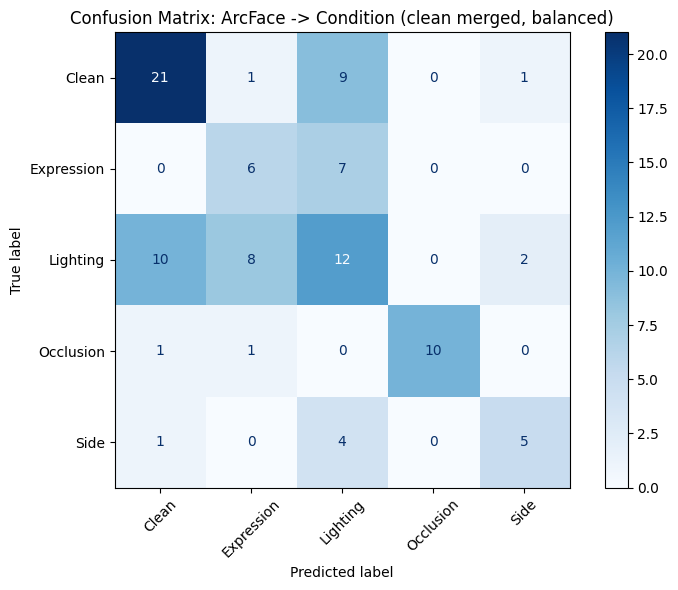


Severity proxy (mean model confidence per true condition):
lower = more ambiguous / harder for the model = acts as a severity signal
condition
Lighting      0.782737
Occlusion     0.814683
Side          0.817677
Clean         0.863071
Expression    0.869274
Name: confidence, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

#merge clean and clean_probe into a single clean class
#they are not different conditions, they are different dataset splits of the same condition
#keeping them separate asks the model to distinguish gallery from probe, which is not the task
def merge_clean(cond):
    if cond in ('clean', 'clean_probe'):
        return 'Clean'
    return cond

train_arcface = train_df[train_df['model'] == 'ArcFace'].copy()
test_arcface  = test_df[test_df['model'] == 'ArcFace'].copy()

train_arcface['cond_merged'] = train_arcface['condition'].map(merge_clean)
test_arcface['cond_merged']  = test_arcface['condition'].map(merge_clean)

#stack features and labels
X_train_arc_cond = np.vstack(train_arcface['embedding'].values)
y_train_arc_cond = train_arcface['cond_merged'].values

X_test_arc_cond  = np.vstack(test_arcface['embedding'].values)
y_test_arc_cond  = test_arcface['cond_merged'].values

#show class balance so the reader understands the imbalance we are dealing with
print("Test set class counts:")
print(pd.Series(y_test_arc_cond).value_counts())

#use class_weight=balanced to compensate for lighting being ~2x larger than other classes
clf_arc_cond = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf_arc_cond.fit(X_train_arc_cond, y_train_arc_cond)

y_pred_arc_cond = clf_arc_cond.predict(X_test_arc_cond)
acc_arc_cond = accuracy_score(y_test_arc_cond, y_pred_arc_cond)

print(f"\nArcFace condition accuracy: {acc_arc_cond:.3f}")
print(classification_report(y_test_arc_cond, y_pred_arc_cond))

#confusion matrix
cm = confusion_matrix(y_test_arc_cond, y_pred_arc_cond, labels=clf_arc_cond.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_arc_cond.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: ArcFace -> Condition (clean merged, balanced)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#severity proxy: mean model confidence per condition
#low confidence = embeddings for that condition are ambiguous / less cleanly separated
probs_arc_cond = clf_arc_cond.predict_proba(X_test_arc_cond)
max_conf = probs_arc_cond.max(axis=1)
conf_by_cond = pd.DataFrame({'condition': y_test_arc_cond, 'confidence': max_conf})
print("\nSeverity proxy (mean model confidence per true condition):")
print("lower = more ambiguous / harder for the model = acts as a severity signal")
print(conf_by_cond.groupby('condition')['confidence'].mean().sort_values())

VGG19 condition accuracy: 0.612
              precision    recall  f1-score   support

       Clean       0.68      0.54      0.60        39
  Expression       0.46      0.50      0.48        22
    Lighting       0.46      0.56      0.51        34
   Occlusion       0.92      0.92      0.92        12
        Side       0.92      0.86      0.89        14

    accuracy                           0.61       121
   macro avg       0.69      0.67      0.68       121
weighted avg       0.63      0.61      0.62       121

--- Condition classification: model comparison ---
ArcFace: 0.545
VGG19:   0.612
Gap:     -0.066


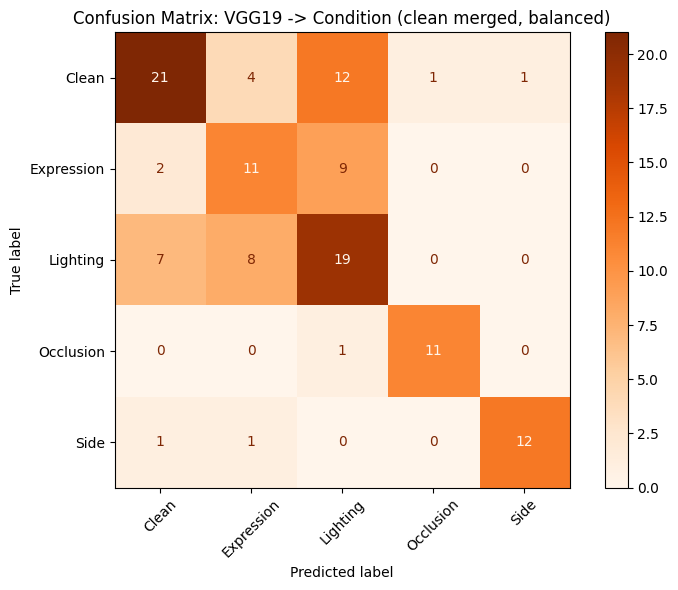


VGG19 severity proxy (mean confidence per condition):
condition
Clean         0.843152
Expression    0.876929
Lighting      0.907892
Side          0.933882
Occlusion     0.970096
Name: confidence, dtype: float64


In [ ]:
#same fixes applied to vgg19 for consistency
#merge clean and clean_probe, use class_weight balanced to offset lighting imbalance
train_vgg = train_df[train_df['model'] == 'VGG19'].copy()
test_vgg  = test_df[test_df['model'] == 'VGG19'].copy()

train_vgg['cond_merged'] = train_vgg['condition'].map(merge_clean)
test_vgg['cond_merged']  = test_vgg['condition'].map(merge_clean)

#stack features and labels
X_train_vgg_cond = np.vstack(train_vgg['embedding'].values)
y_train_vgg_cond = train_vgg['cond_merged'].values

X_test_vgg_cond = np.vstack(test_vgg['embedding'].values)
y_test_vgg_cond = test_vgg['cond_merged'].values

#train on vgg features
clf_vgg_cond = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf_vgg_cond.fit(X_train_vgg_cond, y_train_vgg_cond)

y_pred_vgg_cond = clf_vgg_cond.predict(X_test_vgg_cond)
acc_vgg_cond = accuracy_score(y_test_vgg_cond, y_pred_vgg_cond)

print(f"VGG19 condition accuracy: {acc_vgg_cond:.3f}")
print(classification_report(y_test_vgg_cond, y_pred_vgg_cond))

#side by side comparison of the two feature extractors on the condition task
print("--- Condition classification: model comparison ---")
print(f"ArcFace: {acc_arc_cond:.3f}")
print(f"VGG19:   {acc_vgg_cond:.3f}")
print(f"Gap:     {acc_arc_cond - acc_vgg_cond:+.3f}")

#confusion matrix for vgg
cm_vgg = confusion_matrix(y_test_vgg_cond, y_pred_vgg_cond, labels=clf_vgg_cond.classes_)
disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=clf_vgg_cond.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_vgg.plot(ax=ax, cmap='Oranges')
plt.title('Confusion Matrix: VGG19 -> Condition (clean merged, balanced)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#severity proxy for vgg19
probs_vgg_cond = clf_vgg_cond.predict_proba(X_test_vgg_cond)
max_conf_vgg = probs_vgg_cond.max(axis=1)
conf_by_cond_vgg = pd.DataFrame({'condition': y_test_vgg_cond, 'confidence': max_conf_vgg})
print("\nVGG19 severity proxy (mean confidence per condition):")
print(conf_by_cond_vgg.groupby('condition')['confidence'].mean().sort_values())

ArcFace identity accuracy: 1.000
                   precision    recall  f1-score   support

            Dylan       1.00      1.00      1.00         9
             Jack       1.00      1.00      1.00        12
    Jalen Brunson       1.00      1.00      1.00         8
   Kim Kardashian       1.00      1.00      1.00        14
Leonardo DiCaprio       1.00      1.00      1.00        13
        Megan Fox       1.00      1.00      1.00        11
             Nico       1.00      1.00      1.00         6
     Taylor Swift       1.00      1.00      1.00         6
       Tom Cruise       1.00      1.00      1.00         8
       Will Smith       1.00      1.00      1.00        12

         accuracy                           1.00        99
        macro avg       1.00      1.00      1.00        99
     weighted avg       1.00      1.00      1.00        99



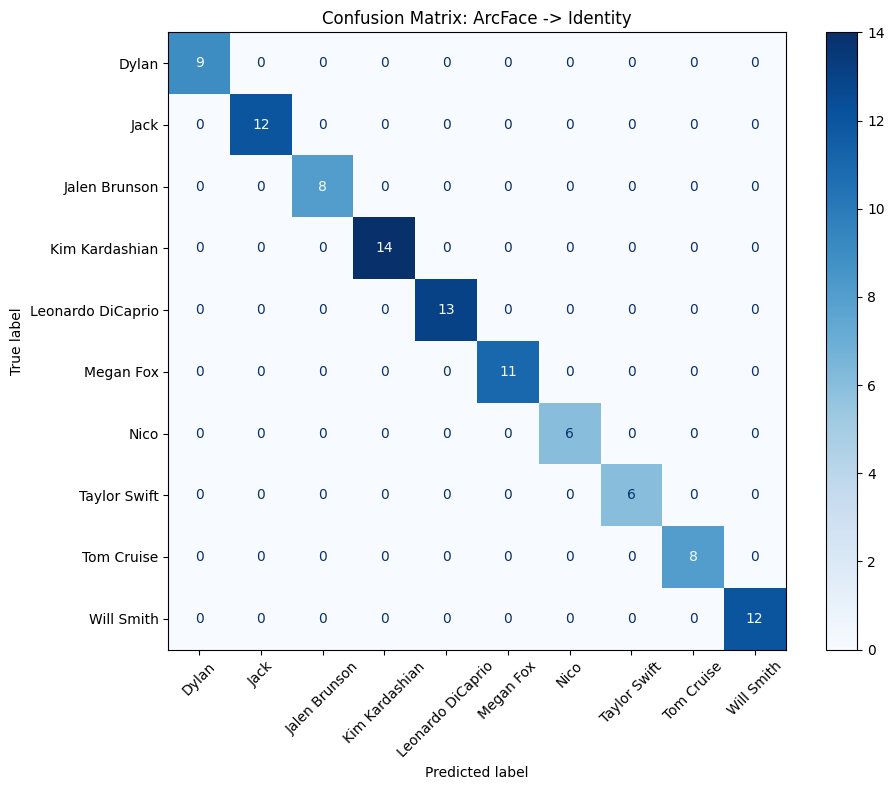

In [ ]:
#identity classification using base_identity as the label
#this is the core re-identification task
X_train_arc_id = np.vstack(train_arcface['embedding'].values)
y_train_arc_id = train_arcface['base_identity'].values

X_test_arc_id = np.vstack(test_arcface['embedding'].values)
y_test_arc_id = test_arcface['base_identity'].values

#train logistic regression one vs rest
clf_arc_id = LogisticRegression(max_iter=1000, random_state=42)
clf_arc_id.fit(X_train_arc_id, y_train_arc_id)

y_pred_arc_id = clf_arc_id.predict(X_test_arc_id)
acc_arc_id = accuracy_score(y_test_arc_id, y_pred_arc_id)

print(f"ArcFace identity accuracy: {acc_arc_id:.3f}")
print(classification_report(y_test_arc_id, y_pred_arc_id))

#confusion matrix to see which identities get confused
cm = confusion_matrix(y_test_arc_id, y_pred_arc_id, labels=clf_arc_id.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_arc_id.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: ArcFace -> Identity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

VGG19 identity accuracy: 0.810
                   precision    recall  f1-score   support

            Dylan       1.00      1.00      1.00         9
             Jack       1.00      1.00      1.00        10
    Jalen Brunson       0.88      0.94      0.91        16
   Kim Kardashian       0.45      0.45      0.45        11
Leonardo DiCaprio       0.67      0.67      0.67        12
        Megan Fox       0.57      0.89      0.70         9
             Nico       1.00      0.94      0.97        16
     Taylor Swift       1.00      0.62      0.76        13
       Tom Cruise       0.69      0.79      0.73        14
       Will Smith       1.00      0.82      0.90        11

         accuracy                           0.81       121
        macro avg       0.83      0.81      0.81       121
     weighted avg       0.83      0.81      0.81       121

--- Identity classification: model comparison ---
ArcFace: 1.000
VGG19:   0.810
Gap:     +0.190


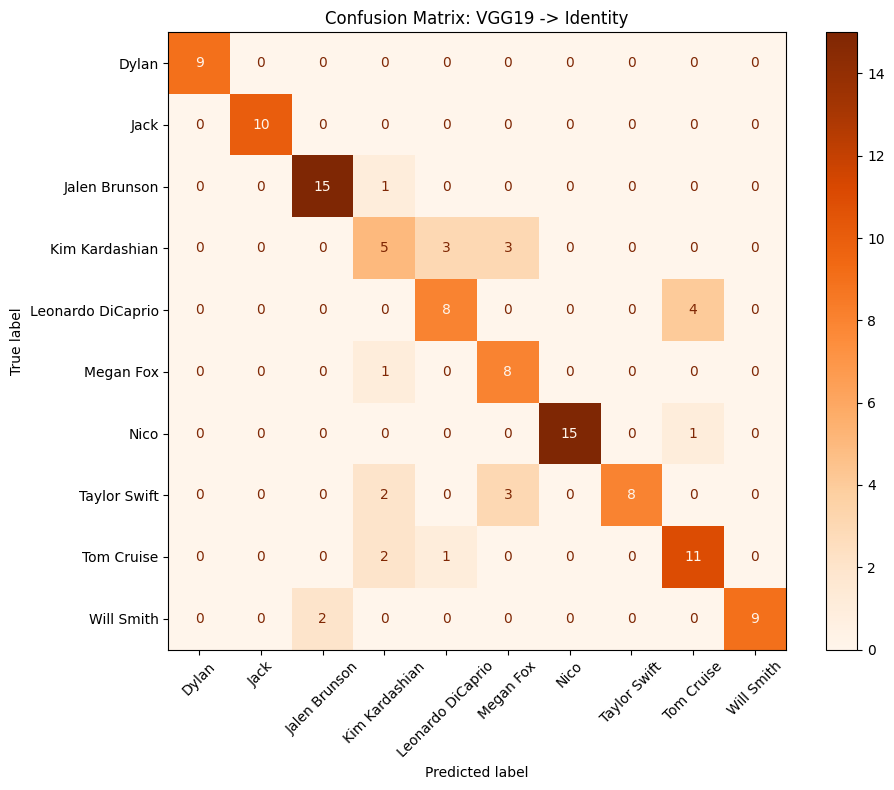

In [ ]:
#same identity task on vgg19 features for direct comparison
X_train_vgg_id = np.vstack(train_vgg['embedding'].values)
y_train_vgg_id = train_vgg['base_identity'].values

X_test_vgg_id = np.vstack(test_vgg['embedding'].values)
y_test_vgg_id = test_vgg['base_identity'].values

clf_vgg_id = LogisticRegression(max_iter=1000, random_state=42)
clf_vgg_id.fit(X_train_vgg_id, y_train_vgg_id)

y_pred_vgg_id = clf_vgg_id.predict(X_test_vgg_id)
acc_vgg_id = accuracy_score(y_test_vgg_id, y_pred_vgg_id)

print(f"VGG19 identity accuracy: {acc_vgg_id:.3f}")
print(classification_report(y_test_vgg_id, y_pred_vgg_id))

#side by side summary
print("--- Identity classification: model comparison ---")
print(f"ArcFace: {acc_arc_id:.3f}")
print(f"VGG19:   {acc_vgg_id:.3f}")
print(f"Gap:     {acc_arc_id - acc_vgg_id:+.3f}")

#confusion matrix for vgg
cm_vgg_id = confusion_matrix(y_test_vgg_id, y_pred_vgg_id, labels=clf_vgg_id.classes_)
disp_vgg_id = ConfusionMatrixDisplay(confusion_matrix=cm_vgg_id, display_labels=clf_vgg_id.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp_vgg_id.plot(ax=ax, cmap='Oranges')
plt.title('Confusion Matrix: VGG19 -> Identity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#evaluate identity classification accuracy broken down by condition
#the pdf asks to evaluate performance across the range of conditions, this is how
def per_condition_accuracy(y_true, y_pred, conditions, model_name):
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'condition': conditions})
    rows = []
    for cond, group in df.groupby('condition'):
        acc = (group['y_true'] == group['y_pred']).mean()
        rows.append({'Model': model_name, 'Condition': cond, 'Accuracy': acc, 'N': len(group)})
    return pd.DataFrame(rows)

#arcface per condition
cond_arc = test_arcface['condition'].values
arc_breakdown = per_condition_accuracy(y_test_arc_id, y_pred_arc_id, cond_arc, 'ArcFace')

#vgg per condition
cond_vgg = test_vgg['condition'].values
vgg_breakdown = per_condition_accuracy(y_test_vgg_id, y_pred_vgg_id, cond_vgg, 'VGG19')

#combine and pivot for side by side readability
breakdown = pd.concat([arc_breakdown, vgg_breakdown], ignore_index=True)
pivot = breakdown.pivot(index='Condition', columns='Model', values='Accuracy')
pivot['Gap (Arc - VGG)'] = pivot['ArcFace'] - pivot['VGG19']

print("Per-condition identity accuracy on held-out test set:")
print(pivot.round(3))

Per-condition identity accuracy on held-out test set:
Model        ArcFace  VGG19  Gap (Arc - VGG)
Condition                                   
Expression       1.0  0.955            0.045
Lighting         1.0  0.882            0.118
Occlusion        1.0  0.750            0.250
Side             1.0  0.714            0.286
clean            1.0  0.762            0.238
clean_probe      1.0  0.667            0.333


Variance explained by 256 components: 0.984

=== VGG19 Identity: L2 + PCA + LR ===
                   precision    recall  f1-score   support

            Dylan       1.00      1.00      1.00         9
             Jack       1.00      0.90      0.95        10
    Jalen Brunson       0.84      1.00      0.91        16
   Kim Kardashian       0.46      0.55      0.50        11
Leonardo DiCaprio       0.60      0.75      0.67        12
        Megan Fox       0.75      0.67      0.71         9
             Nico       0.94      0.94      0.94        16
     Taylor Swift       0.89      0.62      0.73        13
       Tom Cruise       0.62      0.57      0.59        14
       Will Smith       0.90      0.82      0.86        11

         accuracy                           0.79       121
        macro avg       0.80      0.78      0.78       121
     weighted avg       0.80      0.79      0.79       121

--- Accuracy comparison ---
ArcFace baseline LR:      1.000
VGG19 raw LR:             0.

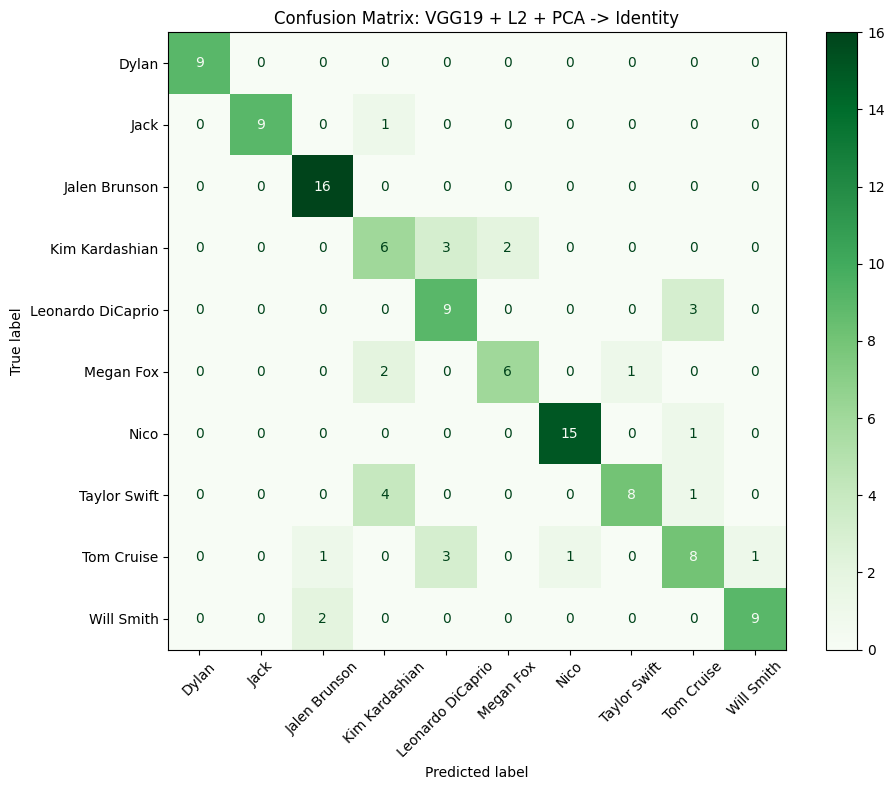

In [ ]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

#approach A from the pdf: preprocess vgg features then train LR on top
#l2 normalize so euclidean distance in feature space approximates cosine similarity
X_train_norm = normalize(X_train_vgg_id, norm='l2')
X_test_norm  = normalize(X_test_vgg_id,  norm='l2')

#pca from 4096 down to 256 dimensions, fit on training data only to avoid leakage
pca = PCA(n_components=256, random_state=42)
X_train_pca = pca.fit_transform(X_train_norm)
X_test_pca  = pca.transform(X_test_norm)

print(f"Variance explained by 256 components: {pca.explained_variance_ratio_.sum():.3f}")

#retrain logistic regression on the reduced normalized features
clf_vgg_pca = LogisticRegression(max_iter=1000, random_state=42)
clf_vgg_pca.fit(X_train_pca, y_train_vgg_id)

y_pred_pca = clf_vgg_pca.predict(X_test_pca)
acc_vgg_pca = accuracy_score(y_test_vgg_id, y_pred_pca)

print("\n=== VGG19 Identity: L2 + PCA + LR ===")
print(classification_report(y_test_vgg_id, y_pred_pca))

#compare against the other identity pipelines we have so far
print("--- Accuracy comparison ---")
print(f"ArcFace baseline LR:      {acc_arc_id:.3f}")
print(f"VGG19 raw LR:             {acc_vgg_id:.3f}")
print(f"VGG19 + L2 + PCA + LR:    {acc_vgg_pca:.3f}")

#confusion matrix for the pca variant
cm_pca = confusion_matrix(y_test_vgg_id, y_pred_pca, labels=clf_vgg_pca.classes_)
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=clf_vgg_pca.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp_pca.plot(ax=ax, cmap='Greens')
plt.title('Confusion Matrix: VGG19 + L2 + PCA -> Identity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

#use gpu if available, cpu is fine too since this is a tiny model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

#reuse the same vgg splits so evaluation is still on the held out set
X_train_nn = np.vstack(train_vgg['embedding'].values).astype(np.float32)
X_test_nn  = np.vstack(test_vgg['embedding'].values).astype(np.float32)

#encode identity names as integers 0..9 for crossentropy loss
le = LabelEncoder()
y_train_nn = le.fit_transform(train_vgg['base_identity'].values)
y_test_nn  = le.transform(test_vgg['base_identity'].values)
num_classes = len(le.classes_)

#small mlp head with batchnorm and dropout to regularize
#keeps vgg weights frozen, only trains this head
class VGGHead(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=512, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.net(x)

#wrap numpy arrays in a torch dataset
class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(EmbeddingDataset(X_train_nn, y_train_nn), batch_size=32, shuffle=True)
test_loader  = DataLoader(EmbeddingDataset(X_test_nn,  y_test_nn),  batch_size=32, shuffle=False)

#loss, optimizer, and a step scheduler that halves lr every 20 epochs
model_head = VGGHead(input_dim=4096, hidden_dim=512, num_classes=num_classes).to(device)
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model_head.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

EPOCHS = 60
best_acc = 0.0
best_state = None

#training loop with eval every 10 epochs so output stays readable
for epoch in range(EPOCHS):
    model_head.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model_head(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    scheduler.step()
    train_loss = running_loss / len(train_loader.dataset)

    if (epoch + 1) % 10 == 0:
        model_head.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model_head(X_batch).argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)
        acc = correct / total

        #save the best checkpoint so our final saved model is our best model
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.cpu().clone() for k, v in model_head.state_dict().items()}

        print(f"Epoch {epoch+1:>3}/{EPOCHS}  train_loss={train_loss:.4f}  test_acc={acc:.3f}  best={best_acc:.3f}")

#final summary using computed variables, not hardcoded strings
print("\n--- Final VGG re-identification summary ---")
print(f"ArcFace LR baseline:      {acc_arc_id:.3f}")
print(f"VGG19 raw LR:             {acc_vgg_id:.3f}")
print(f"VGG19 + L2 + PCA + LR:    {acc_vgg_pca:.3f}")
print(f"VGG19 + neural head:      {best_acc:.3f}")

#save the best state dict, not whatever the last epoch produced
if best_state is not None:
    torch.save(best_state, '/content/drive/MyDrive/vgg19_finetuned_head.pth')
    print("\nBest model head saved to Drive.")

Using device: cuda
Epoch  10/60  train_loss=0.0683  test_acc=0.793  best=0.793
Epoch  20/60  train_loss=0.0234  test_acc=0.818  best=0.818
Epoch  30/60  train_loss=0.0102  test_acc=0.802  best=0.818
Epoch  40/60  train_loss=0.0071  test_acc=0.810  best=0.818
Epoch  50/60  train_loss=0.0059  test_acc=0.785  best=0.818
Epoch  60/60  train_loss=0.0043  test_acc=0.793  best=0.818

--- Final VGG re-identification summary ---
ArcFace LR baseline:      1.000
VGG19 raw LR:             0.810
VGG19 + L2 + PCA + LR:    0.785
VGG19 + neural head:      0.818

Best model head saved to Drive.


In [ ]:
#handles any identity missing from the gallery not just Dylan
#validates on held-out probes with seeded rows excluded to prevent leakage

import pickle
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

#build base gallery from arcface clean gallery images only
#these are the reference vectors we compare unknowns against
gallery_base = embeddings_df[
    (embeddings_df['model'] == 'ArcFace') &
    (embeddings_df['split'] == 'Gallery')
].copy()

#auto-patch any identity with zero gallery images
#stage 2 missed Dylan so we seed from clean_probe which are frontal baseline shots
#this generalizes so if any other identity is missing it gets handled too
all_identities     = embeddings_df['base_identity'].unique()
gallery_identities = gallery_base['base_identity'].unique()
missing            = set(all_identities) - set(gallery_identities)

seed_frames      = [gallery_base]
seeded_filenames = set()

for identity in sorted(missing):
    #prefer clean_probe since those are frontal no-alteration shots
    candidate = embeddings_df[
        (embeddings_df['model'] == 'ArcFace') &
        (embeddings_df['base_identity'] == identity) &
        (embeddings_df['condition'] == 'clean_probe')
    ]
    if len(candidate) == 0:
        #fall back to any probe rows if clean_probe is also missing
        candidate = embeddings_df[
            (embeddings_df['model'] == 'ArcFace') &
            (embeddings_df['base_identity'] == identity)
        ].head(10)
        print(f'  [{identity}] no clean_probe found, seeding with {len(candidate)} general probe images')
    else:
        print(f'  [{identity}] seeded with {len(candidate)} clean_probe images')

    seeded_filenames.update(candidate['filename'].values)
    seed_frames.append(candidate)

gallery_df_final   = pd.concat(seed_frames, ignore_index=True)
gallery_embeddings = np.vstack(gallery_df_final['embedding'].values)
gallery_labels     = gallery_df_final['base_identity'].values

print(f'\nGallery size : {len(gallery_labels)} images')
print(f'Identities   : {sorted(np.unique(gallery_labels))}')
print(pd.Series(gallery_labels).value_counts().sort_index().to_string())

#identify is the challenge-ready wrapper
#defaults on gallery_emb and gallery_lbl mean in-class you can just call identify(vec)
def identify(unknown_vector,
             gallery_emb=gallery_embeddings,
             gallery_lbl=gallery_labels,
             top_k=3,
             verbose=False):

    #Given a single ArcFace embedding vector, returns the most likely identity.

    vec  = np.array(unknown_vector).reshape(1, -1)
    sims = cosine_similarity(vec, gallery_emb)[0]

    top_idx     = sims.argsort()[::-1][:top_k]
    top_matches = [(gallery_lbl[i], float(sims[i])) for i in top_idx]

    if verbose:
        print(f'Top-{top_k} matches:')
        for rank, (name, score) in enumerate(top_matches, 1):
            flag = ' <- predicted' if rank == 1 else ''
            print(f'  {rank}. {name:<22} similarity={score:.4f}{flag}')

    return top_matches[0][0]

#validate on held-out probe set
#exclude seeded rows to avoid leakage since we just put some in the gallery
test_arc      = test_df[test_df['model'] == 'ArcFace']
test_arc_eval = test_arc[~test_arc['filename'].isin(seeded_filenames)]

X_probe = np.vstack(test_arc_eval['embedding'].values)
y_probe = test_arc_eval['base_identity'].values

correct = sum(
    identify(vec) == true_label
    for vec, true_label in zip(X_probe, y_probe)
)

print(f'\n--- identify() validation on held-out probe set ---')
print(f'Probe images evaluated : {len(y_probe)}')
print(f'Correct identifications: {correct}')
print(f'Accuracy               : {correct / len(y_probe):.3f}')

#demo verbose call so you see what the function prints in class
print('\nExample verbose call on first probe vector:')
print(f'True label: {y_probe[0]}')
_ = identify(X_probe[0], top_k=3, verbose=True)

#save final gallery for in-class use
with open('/content/drive/MyDrive/gallery_embeddings.pkl', 'wb') as f:
    pickle.dump({'embeddings': gallery_embeddings, 'labels': gallery_labels}, f)


  [Dylan] no clean_probe found, seeding with 10 general probe images

Gallery size : 105 images
Identities   : ['Dylan', 'Jack', 'Jalen Brunson', 'Kim Kardashian', 'Leonardo DiCaprio', 'Megan Fox', 'Nico', 'Taylor Swift', 'Tom Cruise', 'Will Smith']
Dylan                10
Jack                  6
Jalen Brunson        12
Kim Kardashian       12
Leonardo DiCaprio    11
Megan Fox            11
Nico                  8
Taylor Swift         12
Tom Cruise           11
Will Smith           12

--- identify() validation on held-out probe set ---
Probe images evaluated : 97
Correct identifications: 97
Accuracy               : 1.000

Example verbose call on first probe vector:
True label: Megan Fox
Top-3 matches:
  1. Megan Fox              similarity=0.6894 <- predicted
  2. Megan Fox              similarity=0.6636
  3. Megan Fox              similarity=0.6556


  STAGE 3 UNIFIED CLASSIFIER COMPARISON
  All accuracies on held-out test set (20%). NaN = condition absent in test split.
                                 Overall  Clean  Expression  Lighting  Occlusion  Side
Task      Classifier                                                                  
Condition ArcFace - LR             0.545  0.656       0.462     0.375      0.833 0.500
          VGG19 - LR               0.612  0.538       0.500     0.559      0.917 0.857
Identity  ArcFace - LR             1.000  1.000       1.000     1.000      1.000 1.000
          VGG19 - LR (raw)         0.810  0.718       0.955     0.882      0.750 0.714
          VGG19 - L2 + PCA + LR    0.785  0.744       0.864     0.824      0.667 0.786
          VGG19 - MLP head         0.818  0.744       0.818     0.912      0.750 0.857


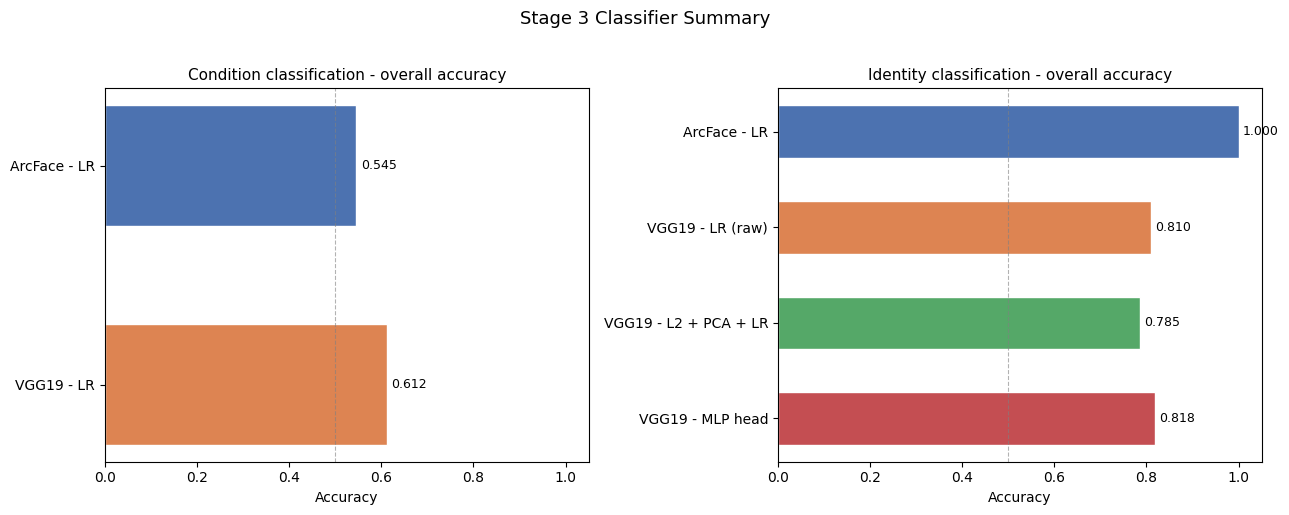

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

#recover MLP predictions as identity name strings
model_head.load_state_dict(best_state)
model_head.eval()

all_nn_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = model_head(X_batch).argmax(dim=1).cpu().numpy()
        all_nn_preds.extend(preds)

y_pred_mlp = le.inverse_transform(np.array(all_nn_preds))

#merge raw condition labels into 5 display classes
#clean and clean_probe are the same condition split across gallery vs probe
#so we collapse them for a cleaner per-condition breakdown
DISPLAY_CONDITIONS = ['Clean', 'Expression', 'Lighting', 'Occlusion', 'Side']

def merge_for_display(c):
    return 'Clean' if c in ('clean', 'clean_probe') else c

cond_arc_display = np.array([merge_for_display(c) for c in test_arcface['condition'].values])
cond_vgg_display = np.array([merge_for_display(c) for c in test_vgg['condition'].values])

#helper builds one summary row with overall acc and per-condition acc
def summary_row(name, task, y_true, y_pred, conditions_arr):
    row = {'Classifier': name, 'Task': task,
           'Overall': accuracy_score(y_true, y_pred)}
    for cond in DISPLAY_CONDITIONS:
        mask = (conditions_arr == cond)
        row[cond] = accuracy_score(y_true[mask], y_pred[mask]) if mask.sum() > 0 else float('nan')
    return row

#build rows for every classifier we trained
#condition classifiers use the condition labels as both y_true and the grouping
#identity classifiers pull conditions from the matching test subset
rows = [
    summary_row('ArcFace - LR',            'Condition',
                y_test_arc_cond, y_pred_arc_cond, y_test_arc_cond),
    summary_row('VGG19 - LR',              'Condition',
                y_test_vgg_cond, y_pred_vgg_cond, y_test_vgg_cond),

    summary_row('ArcFace - LR',            'Identity',
                y_test_arc_id, y_pred_arc_id, cond_arc_display),
    summary_row('VGG19 - LR (raw)',        'Identity',
                y_test_vgg_id, y_pred_vgg_id, cond_vgg_display),
    summary_row('VGG19 - L2 + PCA + LR',   'Identity',
                y_test_vgg_id, y_pred_pca,    cond_vgg_display),
    summary_row('VGG19 - MLP head',        'Identity',
                y_test_vgg_id, y_pred_mlp,    cond_vgg_display),
]

summary_df = pd.DataFrame(rows).set_index(['Task', 'Classifier'])

#display table with nice formatting
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)

print('=' * 90)
print('  STAGE 3 UNIFIED CLASSIFIER COMPARISON')
print('  All accuracies on held-out test set (20%). NaN = condition absent in test split.')
print('=' * 90)
print(summary_df.to_string())
print('=' * 90)

#side by side bar chart of overall accuracy per task
#dashed line at 0.5 gives a visual reference for chance-ish performance
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, task in zip(axes, ['Condition', 'Identity']):
    subset = summary_df.loc[task].reset_index()
    bars = ax.barh(subset['Classifier'], subset['Overall'],
                   color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'][:len(subset)],
                   edgecolor='white', height=0.55)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Accuracy')
    ax.set_title(f'{task} classification - overall accuracy', fontsize=11)
    ax.axvline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{w:.3f}', va='center', fontsize=9)
    ax.invert_yaxis()

plt.suptitle('Stage 3 Classifier Summary', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()